In [76]:
import pandas as pd
df = pd.read_csv('/Users/ekaterinastepura/Downloads/df_labeled_all_final22.csv')
df.loc[:, "gender_accused"] = df["gender_accused"].map({"мужчина": 1, "женщина": 0})
df.loc[:, "prior_convictions"] = df["prior_convictions"].map({"да": 1, "нет": 0})
df.loc[:, "alcohol"] = df["alcohol"].map({"да": 1, "нет": 0})
df['has_man_victim'] = df['has_man_victim'].astype(int)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37755 entries, 0 to 37754
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        37755 non-null  int64  
 1   judge                     37755 non-null  object 
 2   decision                  37755 non-null  object 
 3   gender_accused            37730 non-null  object 
 4   prior_convictions         37738 non-null  object 
 5   alcohol                   37755 non-null  object 
 6   precrime_argument         37755 non-null  int64  
 7   has_woman_victim          37755 non-null  int64  
 8   has_man_victim            37755 non-null  int64  
 9   method                    37755 non-null  object 
 10  motive                    37755 non-null  object 
 11  location                  37755 non-null  object 
 12  prison_term               37585 non-null  float64
 13  many_victims              37755 non-null  int64  
 14  year  

In [78]:
print(df['location'].value_counts())

location
жилое помещение                                                                                                                        27996
уличное пространство                                                                                                                    4459
жилое помещение, уличное пространство                                                                                                   1552
другое                                                                                                                                  1231
жилое помещение, подъезд и прилегающие зоны                                                                                              494
общественное место                                                                                                                       417
подъезд и прилегающие зоны                                                                                                               399
обще

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = df.dropna().reset_index(drop=True)

df['location'] = df['location'].str.replace(', ', ',')

unique_locations = set()
for locations in df['location']:
    unique_locations.update(locations.split(','))

for loc in unique_locations:
    loc_clean = loc.strip()
    df['loc_' + loc_clean] = df['location'].apply(lambda x: int(loc_clean in x.split(',')))

feature_cols = [
    'judge', 'decision', 'gender_accused', 'prior_convictions', 'alcohol',
    'precrime_argument', 'has_woman_victim', 'has_man_victim', 'method', 'motive',
    'prison_term', 'many_victims', 'year', 'season', 'attempt',
    'victim_child_or_helpless', 'cruel', 'region_name'
]
X = df[feature_cols]

y_cols = ['loc_' + loc.strip() for loc in unique_locations]
y_cols = [col for col in y_cols if col in df.columns] 
y = df[y_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}, {y_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}, {y_test.shape}")

Размер обучающей выборки: (30055, 18), (30055, 7)
Размер тестовой выборки: (7514, 18), (7514, 7)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# RandomForest через MultiOutputClassifier
model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))

In [81]:
import numpy as np

print(np.isinf(X_train).sum().sum())
print(np.isinf(X_test).sum().sum())

10
1


In [82]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [83]:
model.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

In [91]:
y_pred = model.predict(X_test)

In [92]:
from sklearn.metrics import f1_score

print("Micro F1 score:", f1_score(y_test, y_pred, average='micro'))
print("Macro F1 score:", f1_score(y_test, y_pred, average='macro'))
print("Macro F1 score:", f1_score(y_test, y_pred, average='weighted'))

Micro F1 score: 0.7841364164836584
Macro F1 score: 0.15019769806559105
Macro F1 score: 0.695864703882941


In [93]:
scores = []
for i, col in enumerate(y_test.columns):
    score = f1_score(y_test[col], y_pred[:, i])
    print(f"{col}: {score:.3f}")
    scores.append(score)

loc_общественный транспорт: 0.000
loc_рабочая зона: 0.000
loc_жилое помещение: 0.899
loc_общественное место: 0.000
loc_уличное пространство: 0.153
loc_подъезд и прилегающие зоны: 0.000
loc_другое: 0.000


In [96]:
import joblib

joblib.dump(model, 'random_forest_multilabel_model.joblib')

['random_forest_multilabel_model.joblib']

In [88]:
model = joblib.load('random_forest_multilabel_model.joblib')

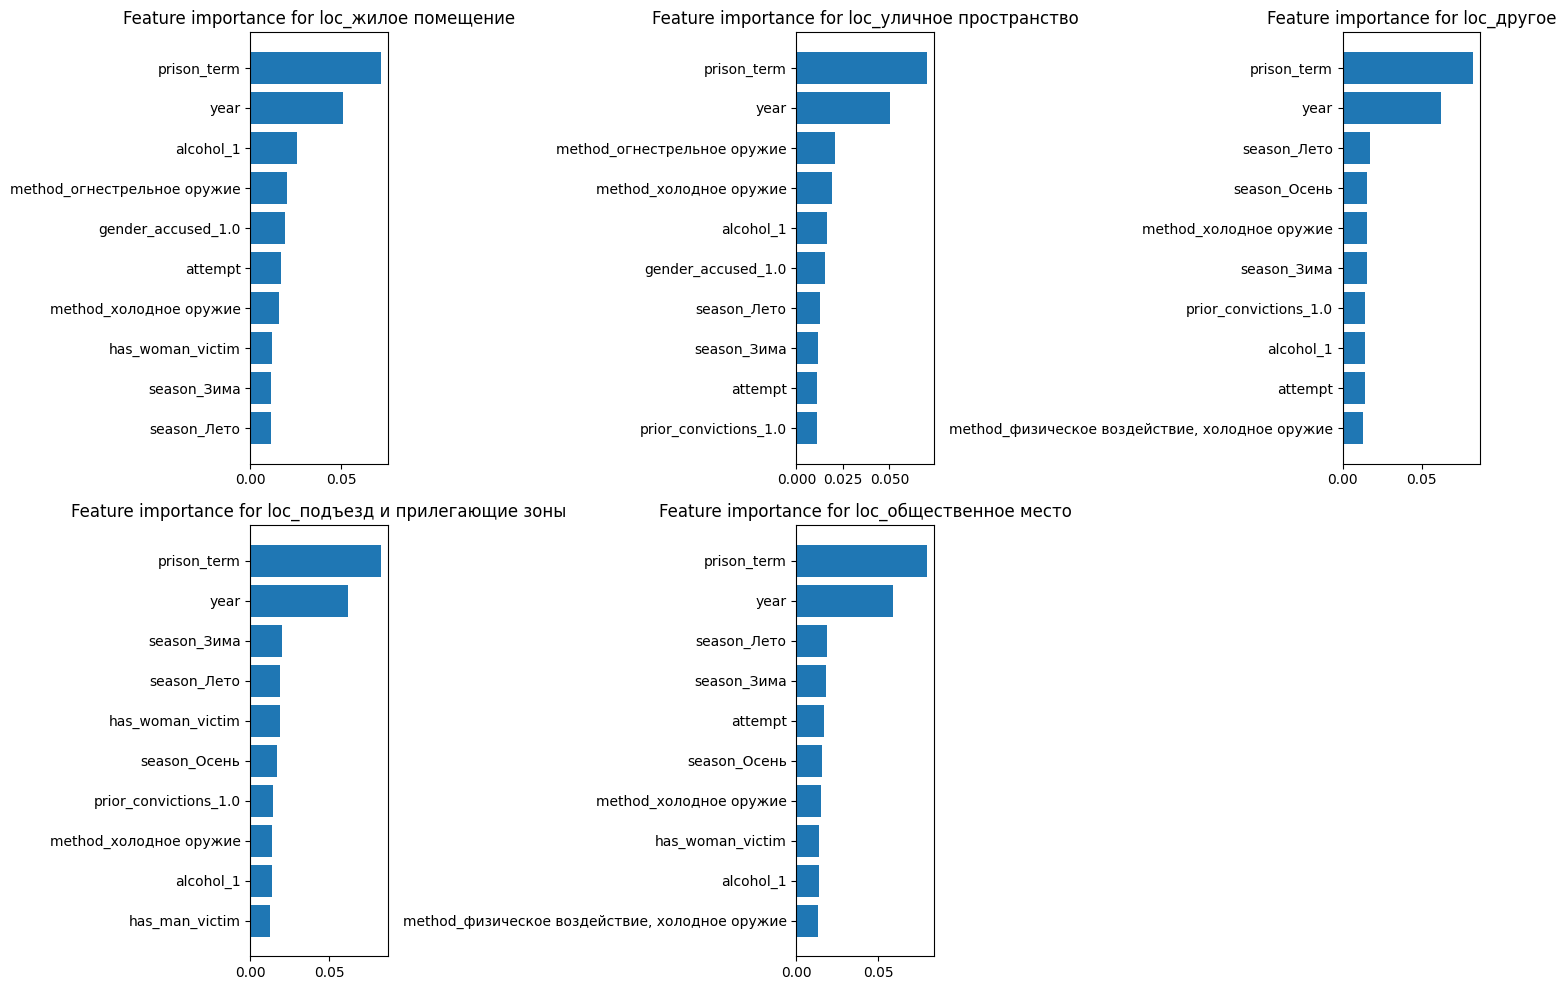

In [95]:
# Выбираем интересующие локации (например, топ-5 по частоте)
top_locations = y.sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(15, 10))
for i, loc in enumerate(top_locations, 1):
    plt.subplot(2, 3, i)
    idx = list(y.columns).index(loc)
    importance = model.estimators_[idx].feature_importances_
    top_features_idx = np.argsort(importance)[-10:]  # топ-10 для этой локации
    plt.barh(X_train.columns[top_features_idx], importance[top_features_idx])
    plt.title(f'Feature importance for {loc}')
plt.tight_layout()
plt.show()

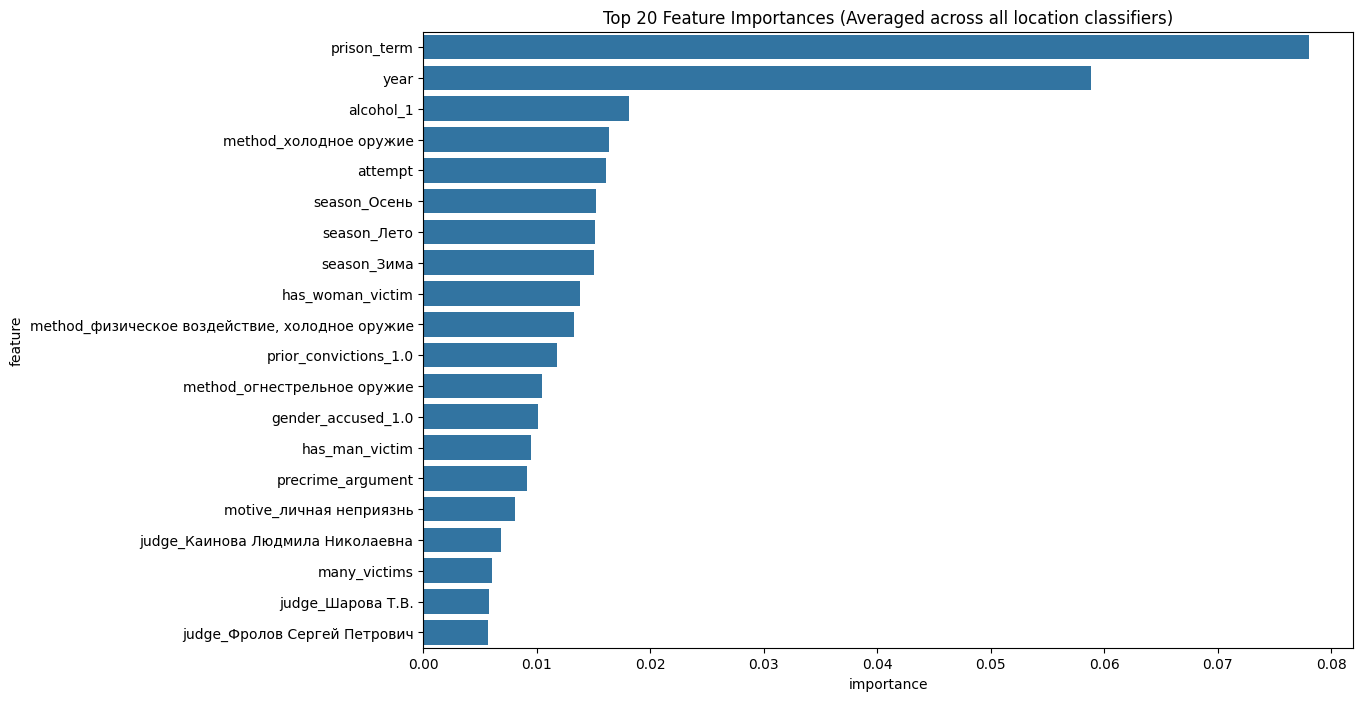

Top 20 важных признаков:
                                             feature  importance
3                                        prison_term    0.078058
5                                               year    0.058833
9145                                       alcohol_1    0.018141
9182                          method_холодное оружие    0.016396
6                                            attempt    0.016109
9286                                    season_Осень    0.015187
9285                                     season_Лето    0.015094
9284                                     season_Зима    0.015033
1                                   has_woman_victim    0.013834
9181  method_физическое воздействие, холодное оружие    0.013318


In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Получаем важность признаков из каждого классификатора
feature_importances = np.zeros(X_train.shape[1])
for i, estimator in enumerate(model.estimators_):
    feature_importances += estimator.feature_importances_

# Усредняем по всем классификаторам
feature_importances /= len(model.estimators_)

# 2. Создаем DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

# 3. Визуализация топ-20 признаков
plt.figure(figsize=(12, 8))
plt.title("Top 20 Feature Importances (Averaged across all location classifiers)")
sns.barplot(x='importance', y='feature', data=importance_df.head(20))
plt.show()

# 4. Вывод таблицы с важностью признаков
print("Top 20 важных признаков:")
print(importance_df.head(10).to_string())

In [ ]:
# Получаем топ-20 важных признаков
top_features = importance_df.head(20)['feature'].tolist()

# Или задаем вручную нужные признаки (пример)
selected_features = [
    'prison_term',
    'year',
    'alcohol',
    'attempt',
    'method',
    'has_woman_victim',
    'motive',
    'cruel',
    'region',
    'gender_accused'
]